In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi' : 200,
    'image.origin' : 'lower',
    'image.interpolation' : 'nearest',
    'font.size' : 12,
})
from matplotlib.colors import LogNorm

import poppy
from poppy.accel_math import xp
import astropy.units as u

# Fully-polarized field

Example of vector diffraction through a Fraunhofer optical system.

This just sends a linearly-polarized vector field through a halfwave plate at a $\pi/4$ rotation and shows that the output linear polarization flips to the orthogonal state.

In [2]:
npix = 256
D = 1 * u.m
wavelen = 1e-6 * u.m

input_polarization = (1, 0) # input linear polarization
wf = poppy.PolarizedWavefront(input_polarization=input_polarization, npix=npix)

In [3]:
osys = poppy.OpticalSystem(npix=npix)
circ = poppy.CircularAperture(radius=D/2)
hwp = poppy.HalfWavePlate(angle=xp.pi/4) # flip to orthogonal linear polarization
img = poppy.ScalarTransmission()
osys.add_pupil(circ)
osys.add_pupil(hwp)
osys.add_image(img)

In [4]:
psf, wfs = osys.calc_psf(inwave=wf, return_intermediates=True)

1.0 1.0


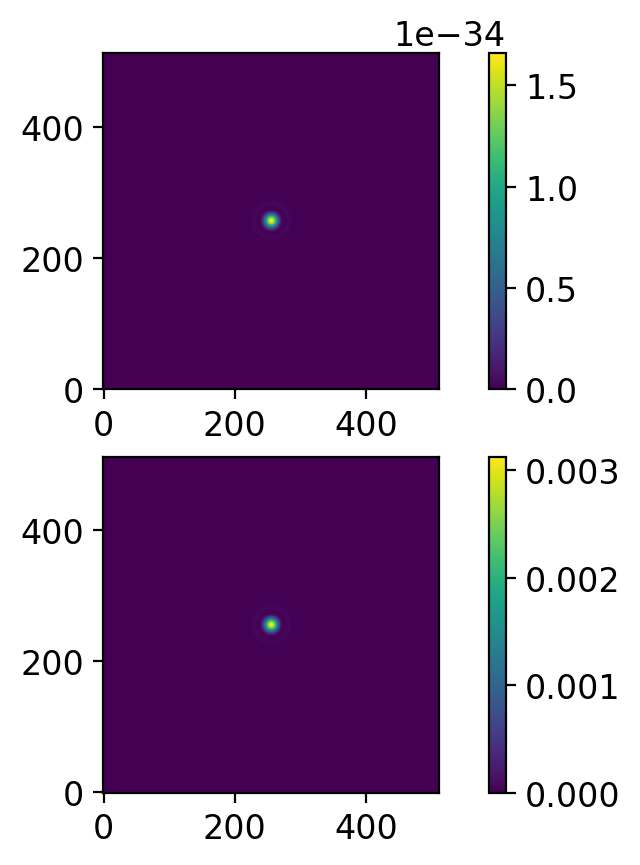

In [5]:
# to be replaced with built-in method! e.g,. wfs.display_vector(what='intensity')

fig, axes = plt.subplots(2, 1)

ax = axes[0]
im = ax.imshow(wfs[-1].amplitude[0]**2)
fig.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(wfs[-1].amplitude[1]**2)
fig.colorbar(im, ax=ax)

print(wfs[0].total_intensity, wfs[-1].total_intensity)

# Partial Polarization

Tensor diffraction with Stokes parameters through a Fresnel optical system.

This sends an unpolarized field through a linear polarizer and quarterwave plate pair and shows that the output stokes vector has converted to circular.

In [6]:
npix = 256
D = 10 * u.mm
wavelen = 630* u.nm

input_stokes_vector = (1, 0, 0, 0) # unpolarized input
wf = poppy.PolarizedFresnelWavefront(D, wavelength=wavelen, npix=npix, input_stokes_vector=input_stokes_vector)

In [7]:
circ = poppy.CircularAperture(radius=D/2)
tl = poppy.QuadraticLens(f_lens=300*u.mm)
# filter unpolarized input for circular polarization
lp = poppy.LinearPolarizer(angle=0)
qwp = poppy.QuarterWavePlate(angle=-xp.pi/4)
#cp = poppy.CircularPolarizer('right')

osys = poppy.FresnelOpticalSystem(npix=npix, pupil_diameter=D)
osys.add_optic(circ)
osys.add_optic(tl)
osys.add_optic(lp, distance=280*u.mm)
osys.add_optic(qwp, distance=10*u.mm)
#osys.add_optic(cp)

In [8]:
psf, wfs = osys.calc_psf(inwave=wf, return_intermediates=True)

Plot the tensor field

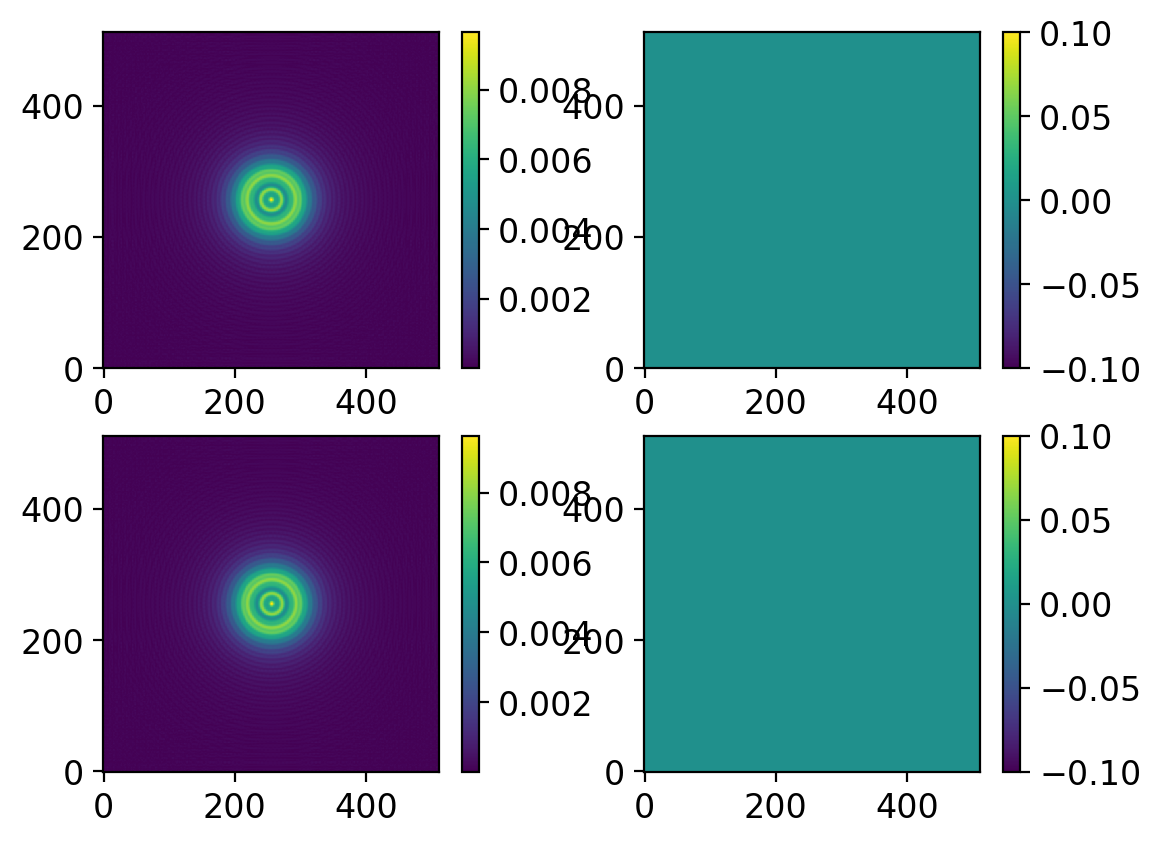

In [9]:
# to be replaced with built-in method! e.g,. wfs.display_tensor()

field = wfs[-1].wavefront
field_idx = [(0,0), (0,1), (1,0), (1,1)]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(xp.abs(field[field_idx[i]]))
    fig.colorbar(im, ax=ax)


Plot the stokes parameters

1.0 0.4999999999999999


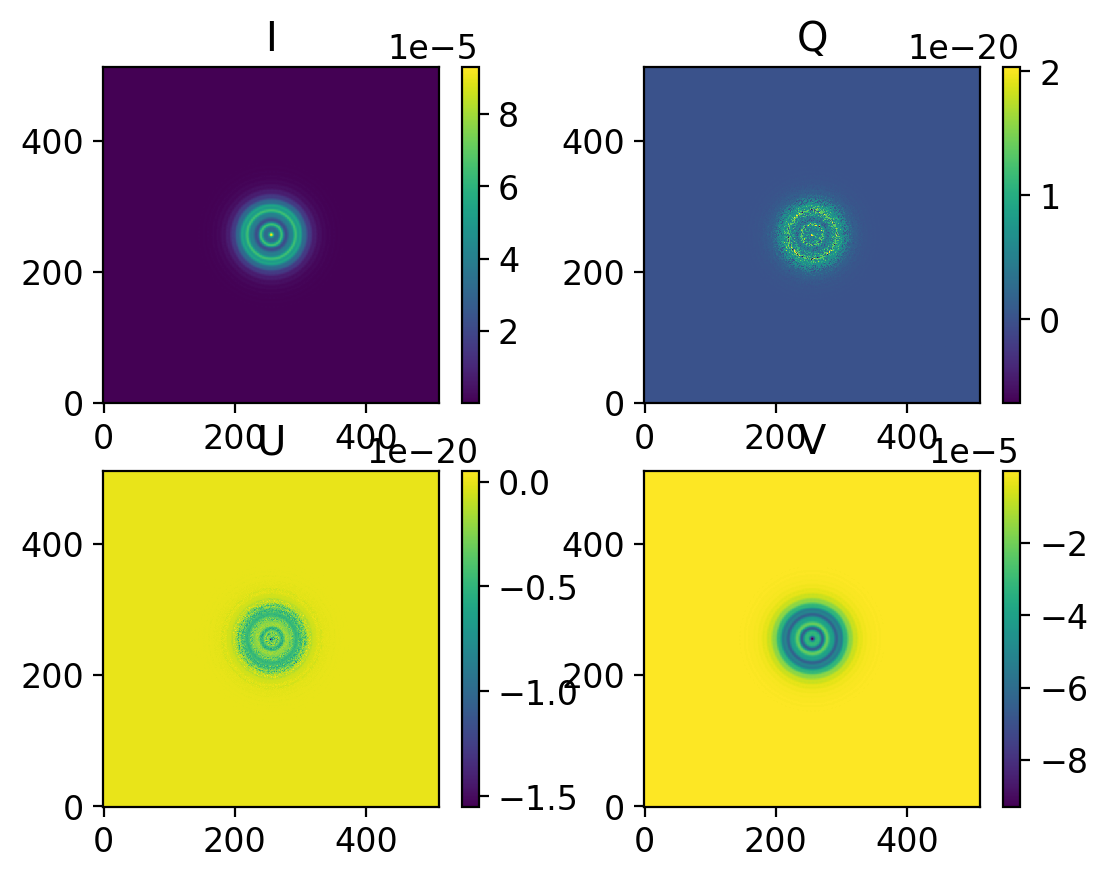

In [10]:
# to be replaced with built-in method! e.g,. wfs.display_stokes()

stokes_out = wfs[-1].stokes_parameters
stokes_names = ['I','Q','U','V']

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(stokes_out[i])
    ax.set_title(stokes_names[i])
    fig.colorbar(im, ax=ax)

print(wfs[0].total_intensity, wfs[-1].total_intensity)